## 資料介紹
資料擷取自以下網站
U.S. Energy Information Administration, Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma [DCOILWTICO], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/DCOILWTICO, August 26, 2026.

## 匯入資料

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/DCOILWTICO.csv")

df["observation_date"] = pd.to_datetime(
    df["observation_date"]
)

## 資料檢查

In [ ]:
# 資料維度
rows, columns = df.shape

print(f"觀測值數量（Rows）: {rows}")
print(f"變數數量（Columns）: {columns}")

# 資料型態
df.info()

觀測值數量（Rows）: 10599
變數數量（Columns）: 2
<class 'pandas.DataFrame'>
RangeIndex: 10599 entries, 0 to 10598
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   observation_date  10599 non-null  datetime64[us]
 1   DCOILWTICO        10226 non-null  float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 165.7 KB


In [3]:
# 檢查是否有缺失值
df.isna().sum()

observation_date      0
DCOILWTICO          373
dtype: int64

In [4]:
missing_dates = df[df["DCOILWTICO"].isna()].copy()
#查看是星期幾
missing_dates["day_of_week"] = missing_dates["observation_date"].dt.day_name()

missing_dates.tail(20)

,observation_date,DCOILWTICO,day_of_week
10174,2025-01-01,NaN,Wednesday
10180,2025-01-09,NaN,Thursday
10187,2025-01-20,NaN,Monday
10207,2025-02-17,NaN,Monday
10251,2025-04-18,NaN,Friday
10277,2025-05-26,NaN,Monday
10295,2025-06-19,NaN,Thursday
10306,2025-07-04,NaN,Friday
10347,2025-09-01,NaN,Monday
10377,2025-10-13,NaN,Monday


發現有缺失值373筆，經檢查發現其散落在週間：  
Monday       189  
Tuesday       17  
Wednesday     19  
Thursday      55  
Friday        93  
不過再進一步檢查發現，其為美股休市日期，近三次為：  
2026-05-25	陣亡將士紀念日 Memorial Day  
2026-06-19	六月節國家獨立日 Juneteenth National Independence Day  
2026-07-03	美國國慶連假 Day before Independence Day  

因此判斷373筆缺失值為「無價格觀測（No Price Observation）」，非資料遺失。

In [ ]:
# 檢查日期有沒有重複
duplicate_dates = df["observation_date"].duplicated().sum()
print(f"重複日期筆數: {duplicate_dates}")


# 日期範圍
print("開始日期:", df["observation_date"].min())
print("結束日期:", df["observation_date"].max())

# 價格資料合理性檢查
print("價格 <= 0 的筆數:", (df["DCOILWTICO"] <= 0).sum())


重複日期筆數: 0
開始日期: 1986-01-02 00:00:00
結束日期: 2026-08-18 00:00:00
價格 <= 0 的筆數: 1


資料中有一筆價格小於等於零的觀測值，發生於 2020-04-20，
價格為 -36.98 USD/barrel，為2020年疫情期間原油市場的極端價格事件。  
雖不將此觀測值視為資料錯誤而刪除，但在後續分析時，需特別注意此值的影響。

## 敘述性統計

In [5]:
# 敘述性統計
df["DCOILWTICO"].describe()

count    10226.000000
mean        48.594287
std         29.595889
min        -36.980000
25%         20.380000
50%         43.830000
75%         71.710000
max        145.310000
Name: DCOILWTICO, dtype: float64

In [98]:
# 依照年份進行敘述性統計
annual_stats = (
    df.groupby(df["observation_date"].dt.year)["DCOILWTICO"]
      .agg(["mean", "min", "max", "std"])
)

annual_stats.head()

,mean,min,max,std
observation_date,,,,
1986,15.047689,10.25,26.53,3.006105
1987,19.200512,15.12,22.44,1.247459
1988,15.965409,12.58,18.54,1.369231
1989,19.635486,16.99,24.62,1.159905
1990,24.526576,15.43,41.07,6.691907


## 資料視覺化、繪圖

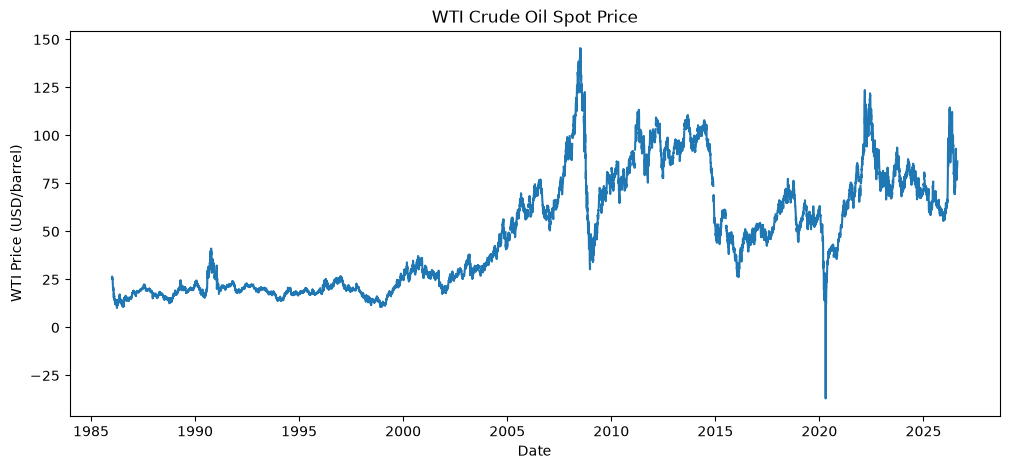

In [96]:
#Price EDA
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    df["observation_date"],
    df["DCOILWTICO"]
)

plt.xlabel("Date")
plt.ylabel("WTI Price (USD/barrel)")
plt.title("WTI Crude Oil Spot Price")

plt.show()

<Figure size 1800x700 with 0 Axes>

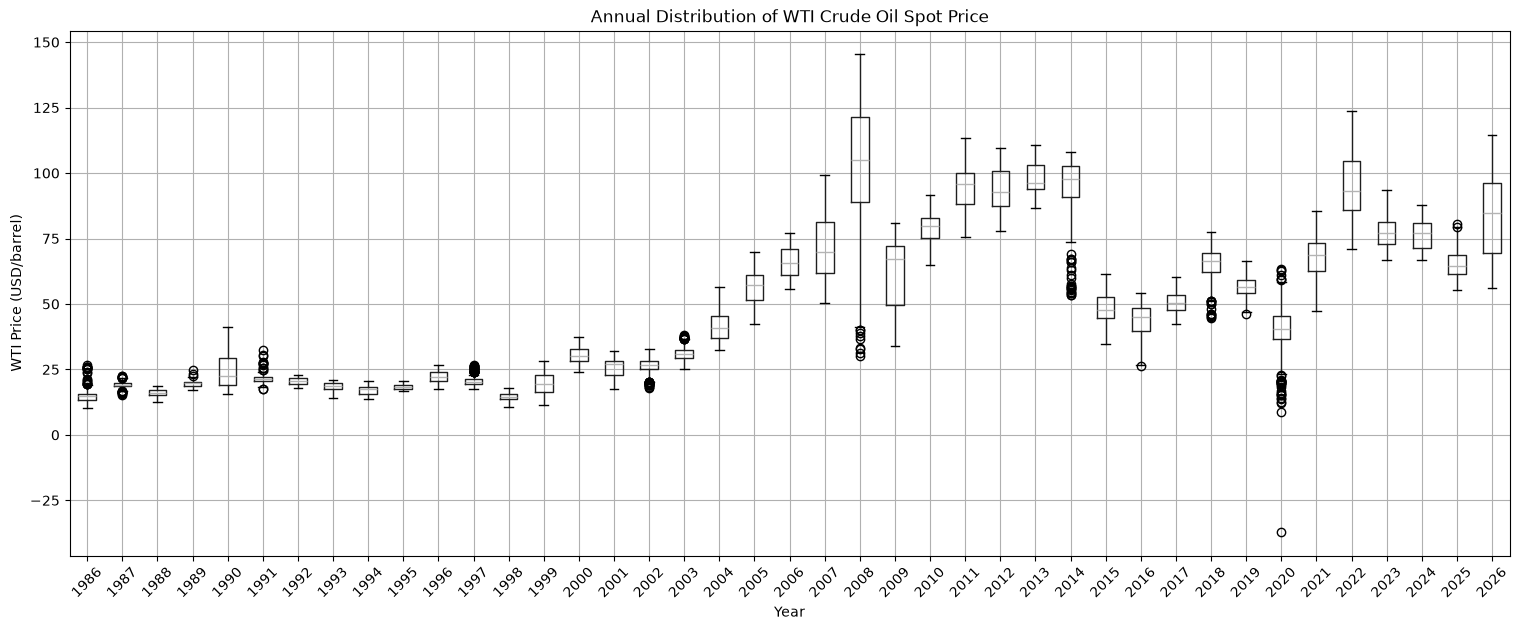

In [99]:
# 每年價格箱型圖
import matplotlib.pyplot as plt

# 建立年份欄位
df["year"] = df["observation_date"].dt.year

plt.figure(figsize=(18, 7))

df.boxplot(
    column="DCOILWTICO",
    by="year",
    figsize=(18, 7)
)

plt.title("Annual Distribution of WTI Crude Oil Spot Price")
plt.suptitle("")  # 移除 pandas 自動產生的標題
plt.xlabel("Year")
plt.ylabel("WTI Price (USD/barrel)")
plt.xticks(rotation=45)

plt.show()

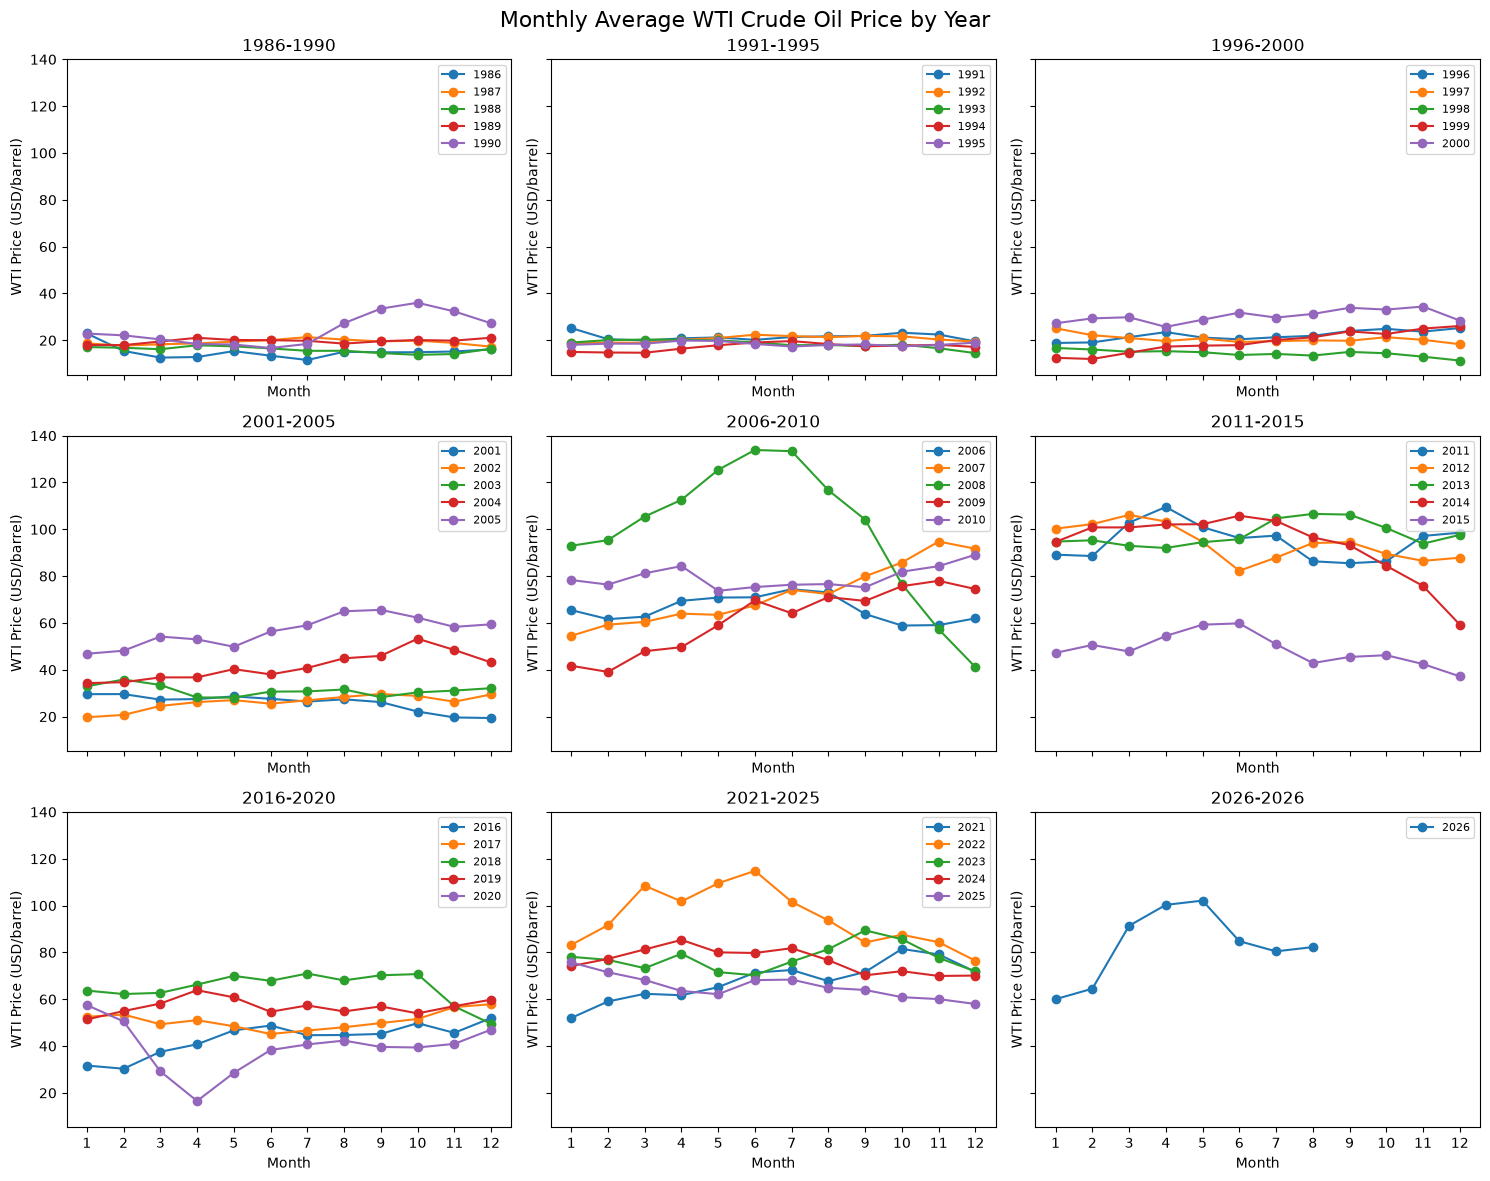

In [ ]:
import math
import matplotlib.pyplot as plt

# 建立年份與月份
df["year"] = df["observation_date"].dt.year
df["month"] = df["observation_date"].dt.month

# 計算每年每月的平均 WTI 價格
monthly_avg = (
    df.groupby(["year", "month"])["DCOILWTICO"]
      .mean()
      .reset_index()
)

# 每 5 年一組
min_year = monthly_avg["year"].min()
max_year = monthly_avg["year"].max()

groups = []

start = min_year

while start <= max_year:
    end = min(start + 4, max_year)
    groups.append((start, end))
    start = end + 1


# 建立 subplot
n = len(groups)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(15, rows * 4),
    sharex=True,
    sharey=True
)

axes = axes.flatten()

for ax, (start_year, end_year) in zip(axes, groups):

    group_data = monthly_avg[
        (monthly_avg["year"] >= start_year) &
        (monthly_avg["year"] <= end_year)
    ]

    for year, data in group_data.groupby("year"):
        ax.plot(
            data["month"],
            data["DCOILWTICO"],
            marker="o",
            label=str(year)
        )

    ax.set_title(f"{start_year}-{end_year}")
    ax.set_xticks(range(1, 13))
    ax.set_xlabel("Month")
    ax.set_ylabel("WTI Price (USD/barrel)")
    ax.legend(fontsize=8)


# 關閉最後有空白 subplot（若有）
for ax in axes[len(groups):]:
    ax.axis("off")

fig.suptitle(
    "Monthly Average WTI Crude Oil Price by Year",
    fontsize=16
)

plt.tight_layout()
plt.show()